<a href="https://colab.research.google.com/github/CharAU1926/GOAT/blob/main/Micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install graphviz


In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
def f(x):
   return 2*x**2-3*x+4
f(9)

139

In [6]:
f(2)

6

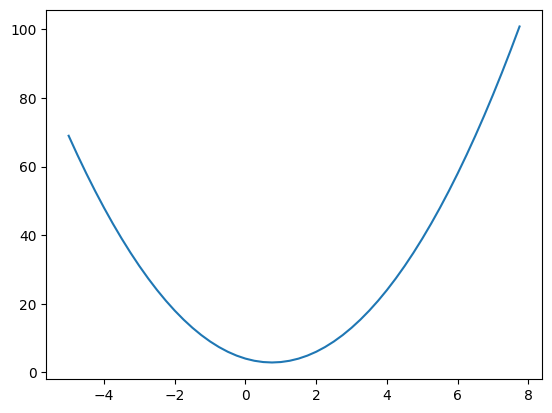

In [7]:
xs = np.arange(-5,8,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [8]:
h = 0.00000001
x = 2
(f(x + h) - f(x))/h

4.999999969612645

In [9]:
# more
a = 4.5
b = 3.2
c = 9.9
d= a*b+c
print (d)

24.3


In [10]:
h = 0.00000001

#inputs
a = 2
b = 2.1
c = 4
d1 = a*b + c
a+= h
d2 = a*b +c
print ('d1',d1)
print ('d2',d2)
print ('slope',(d2-d1)/h)



d1 8.2
d2 8.200000021000001
slope 2.100000173754779


In [11]:


class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # Good practice to handle constants
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
       assert isinstance(other, (int, float)), "only supporting int/float powers for now"
       out = Value(self.data**other, (self,), f'**{other}')

       def _backward():
        self.grad += other * (self.data ** (other -1)) * out.grad
       out._backward = _backward
       return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self,other):
      return self * other**-1

    def __neg__(self):
      return self * -1

    def __sub__(self,other):
      return self +(-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def exp(self):
      x = self.data
      out = Value(math.exp(x), (self,), 'exp')
      def _backward():
        self.grad += out.data * out.grad
      out._backward =_backward
      return out


    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()










In [12]:
 a= Value(2)
 b= Value( 4)
 a - b


Value(data=-2)

In [15]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [16]:
a.grad = -2.0 * 2.0
b.grad = -2.0 * 2.5

In [17]:
def lol():

  h = 0.001
  a = Value(2.5, label = 'a')
  b = Value(2, label = 'b')
  c = Value(4, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L= d * f; L.label = 'L'
  L1 = L.data



  a = Value(2.5 , label = 'a')
  b = Value(2, label = 'b')
  c = Value(4, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0 , label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2-L1)/h)

lol ()

0.0


In [26]:
# inputs x1,x2
x1 = Value(1.0, label='x1')
x2 = Value(2.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.5, label='w2')
# bias of the neuron
b = Value(4, label='b')
# x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh (); o.label = 'o'
o.backward()

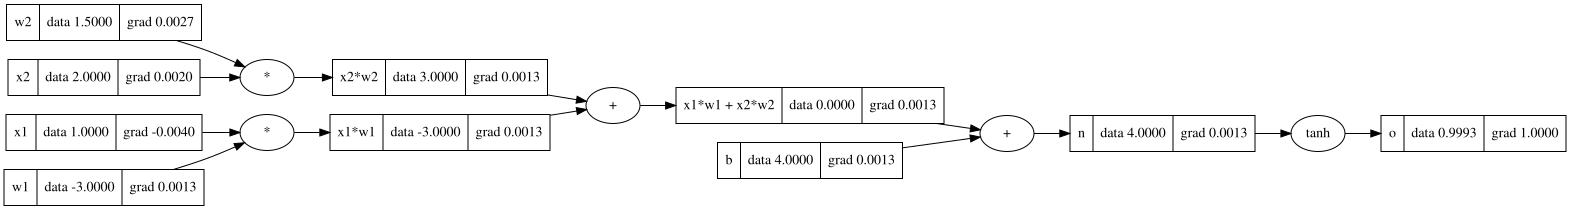

In [27]:
draw_dot(o)

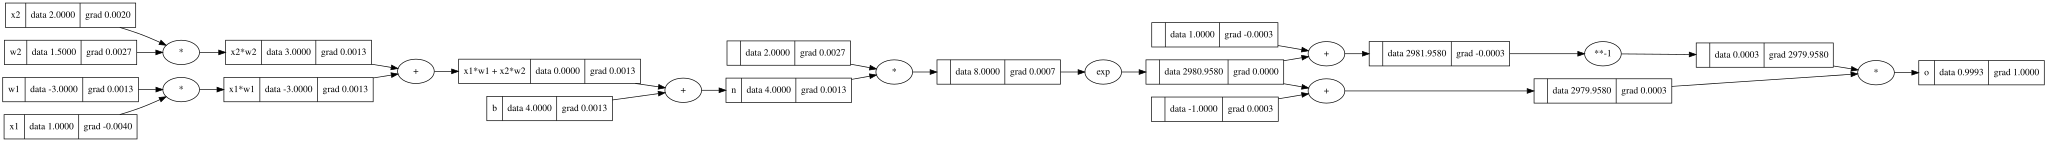

In [28]:
 # inputs x1,x2
x1 = Value(1.0, label='x1')
x2 = Value(2.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.5, label='w2')
# bias of the neuron
b = Value(4, label='b')
# x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# exponent
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

In [50]:
import torch

In [47]:


x1 = torch.Tensor([1.0]).double()                 ; x1.requires_grad = True
x2 = torch.Tensor([2.0]).double()                 ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                ; w1.requires_grad = True
w2 = torch.Tensor([1.5]).double()                 ; w2.requires_grad = True
b = torch.Tensor([4]).double()                    ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())



0.999329299739067
---
x2 0.0020114260245388746
w2 0.002681901366051833
x1 -0.004022852049077749
w1 0.0013409506830259165


In [358]:
import random

class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))


  def __call__(self,x):
   # w * x + b
   act = sum((wi*xi for wi, xi in zip(self.w,x)), self.b)
   out = act.tanh()
   return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:

  def __init__(self , nin ,nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=0.8278265794965746)

In [359]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=0.34190224631324034)

In [299]:
n.parameters()

[Value(data=0.5532317086088274),
 Value(data=-0.08369853122742255),
 Value(data=-0.7122928866905673),
 Value(data=0.7112079279221524),
 Value(data=0.21622007349457295),
 Value(data=-0.680801147142637),
 Value(data=0.039414445817070654),
 Value(data=0.9001965215235617),
 Value(data=-0.5281973604804628),
 Value(data=0.3119603941186566),
 Value(data=0.7569324851700008),
 Value(data=0.5991459721425316),
 Value(data=-0.9717705240482959),
 Value(data=-0.5576686892654019),
 Value(data=-0.49089388604374085),
 Value(data=-0.2512453774461936),
 Value(data=0.1533009361714821),
 Value(data=0.5351939645435144),
 Value(data=0.3709844839797354),
 Value(data=-0.7428451321775842),
 Value(data=0.6365363564017779),
 Value(data=-0.7320553122231235),
 Value(data=0.5038193105909621),
 Value(data=-0.8795237186196498),
 Value(data=0.23594023624212856),
 Value(data=-0.8385788728179724),
 Value(data=-0.658756465435316),
 Value(data=-0.9825866637831719),
 Value(data=0.9644214780851206),
 Value(data=-0.0049419653

In [369]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
    ]
ys=[1.0,-1.0,-1.0,1.0] #desired targets



In [370]:
for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys,ypred)), Value(0))
  #backward pass
  for p in n.parameters():
    p.grad = 00
  loss.backward()
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k,loss.data)

0 0.0006520568739624944
1 0.0006501640902845915
2 0.0006482820129329334
3 0.0006464105522316864
4 0.0006445496194978692
5 0.0006426991270277056
6 0.0006408589880832326
7 0.0006390291168790439
8 0.0006372094285693557
9 0.0006353998392351761
10 0.0006336002658717667
11 0.0006318106263762684
12 0.0006300308395355358
13 0.0006282608250141351
14 0.0006265005033426038
15 0.0006247497959058428
16 0.0006230086249317193
17 0.0006212769134798066
18 0.0006195545854304029
19 0.000617841565473582


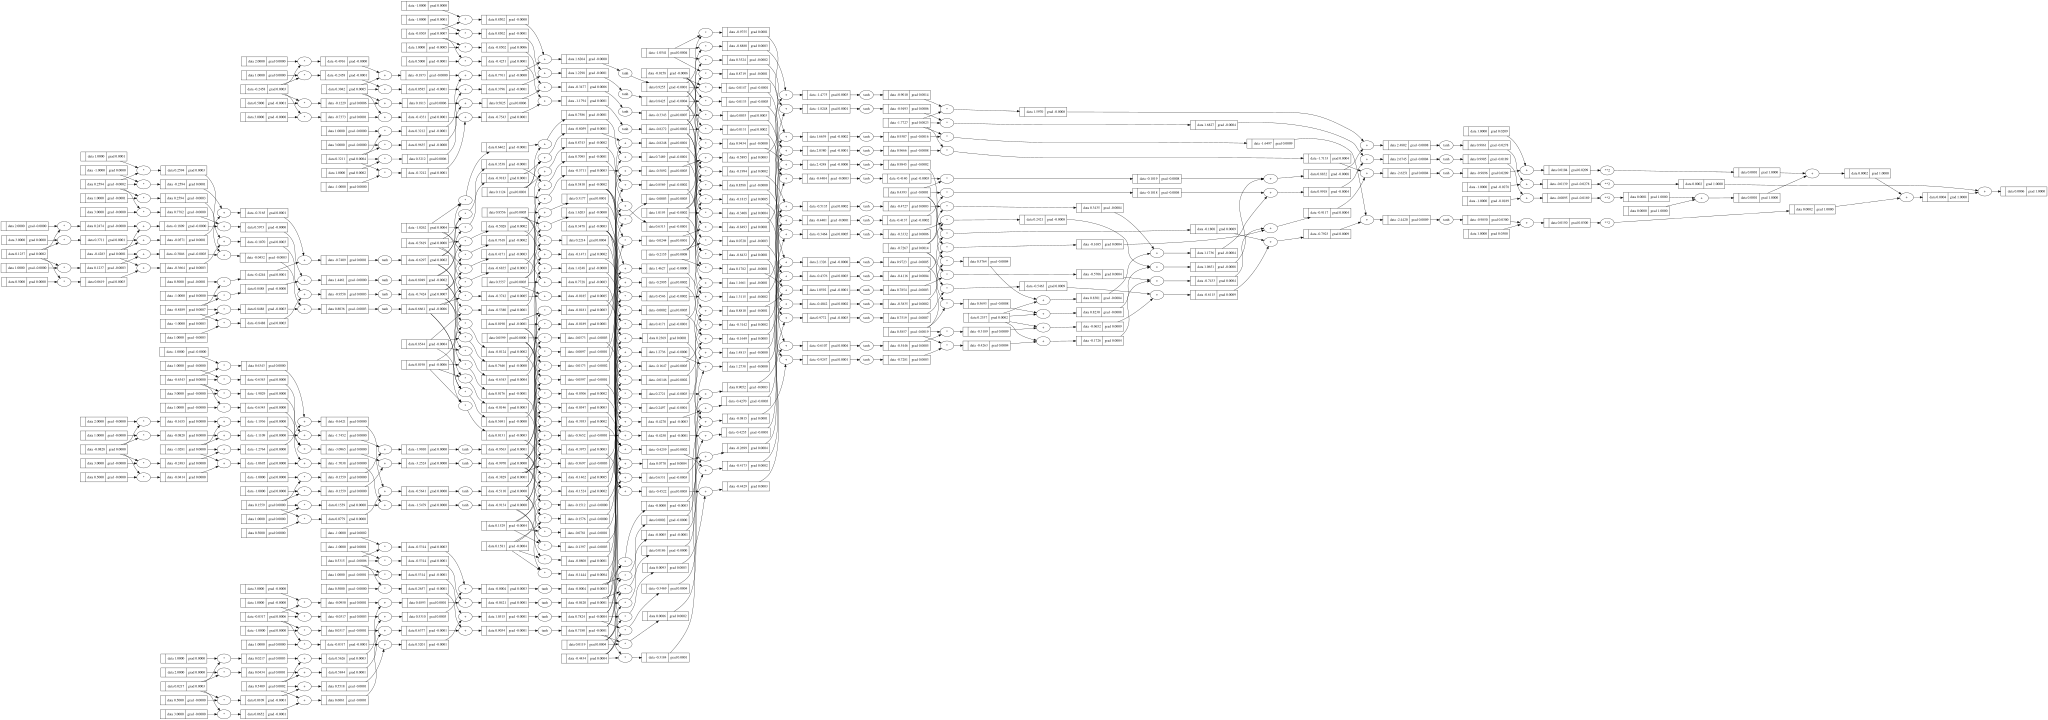

In [373]:
draw_dot(loss)

In [371]:
ypred

[Value(data=0.9905388027522926),
 Value(data=-0.9895611960884777),
 Value(data=-0.9849817340108645),
 Value(data=0.9860784206467111)]

In [22]:
o.grad = 1.0 # Initialize the gradient of the output node to 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
  node._backward()

In [ ]:
o.grad = 2

In [ ]:
o._backward()

In [ ]:
n._backward()

In [ ]:
x1w1x2w2._backward()

In [ ]:
x1w1._backward()

In [ ]:
x2w2._backward()

In [ ]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [ ]:
x2w2.grad = 6.060558083387235
x1w1.grad = 6.060558083387235

In [ ]:
 n.grad = 6.060558083387235e-06

In [ ]:
 # o = tanh(n)
 # do/dn = 1- tanh(n)**2
 1-o.data**2


In [ ]:
o.grad = 1.0

In [ ]:
#dL/de = -2
#e = a*b
#de/da = b
#dL / da = (dl / de) * (de / da)
#dL

In [ ]:
c.grad = -2
e.grad = -2

In [ ]:
#dd/dc = 1.0
 #dd/dc = 1.0
#d= c + e
#((c+h+e))-((c+e))/h
#(c+h+e-c-e)/h
#h/h
#1.0
#dL/dc = (dL/dd) *(dd/dc) =

In [ ]:
#L = d *f
#dl/dd =? f
#derivative of l with respect to d
#dL/df = d
# L with respect to f

In [ ]:
f.grad = 9.000
d.grad = -2.00